In [1]:
#updated for 20 epoch  by him the  man the myth  the  legend
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import numpy as np

# 1. Paths
data_path = 'archive (3)'

# 2. Transformations (smaller image size for speed)
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # smaller = faster
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 3. Load dataset
dataset = datasets.ImageFolder(data_path, transform=transform)
class_names = dataset.classes
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_data, test_data = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False, num_workers=2)

# 4. Model (freeze early layers to reduce compute)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = False  # freeze all layers
for param in model.fc.parameters():
    param.requires_grad = True  # unfreeze final layer

model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

# 5. Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

# 6. Train loop (only 2 epochs) for efficieny and i need  faster my gee
import matplotlib.pyplot as plt

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(2):
    model.train()
    running_loss = 0
    correct, total = 0, 0
    
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    train_losses.append(running_loss / len(train_loader))
    train_accuracy = correct / total
    train_accuracies.append(train_accuracy)
    
    # Validation loop
    model.eval()
    val_loss = 0
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    
    val_losses.append(val_loss / len(test_loader))
    val_accuracy = val_correct / val_total
    val_accuracies.append(val_accuracy)
    
    print(f"Epoch {epoch+1}/2 | Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accuracy:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accuracy:.4f}")

# 7. Evaluate 
model.eval()
all_preds, all_probs, all_labels = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 8. Metrics
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
roc = roc_auc_score(all_labels, all_probs)

print(f"\nAccuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC AUC: {roc:.3f}")
print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=class_names))
print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))


Epoch 1/2 | Train Loss: 0.4883 | Train Acc: 0.8158 | Val Loss: 0.5166 | Val Acc: 0.7993
Epoch 2/2 | Train Loss: 0.4697 | Train Acc: 0.8152 | Val Loss: 0.5079 | Val Acc: 0.8000

Accuracy: 0.800
Precision: 0.800
Recall: 1.000
F1-score: 0.889
ROC AUC: 0.549

Classification Report:
               precision    recall  f1-score   support

     Testing       1.00      0.00      0.01       282
    Training       0.80      1.00      0.89      1123

    accuracy                           0.80      1405
   macro avg       0.90      0.50      0.45      1405
weighted avg       0.84      0.80      0.71      1405

Confusion Matrix:
 [[   1  281]
 [   0 1123]]


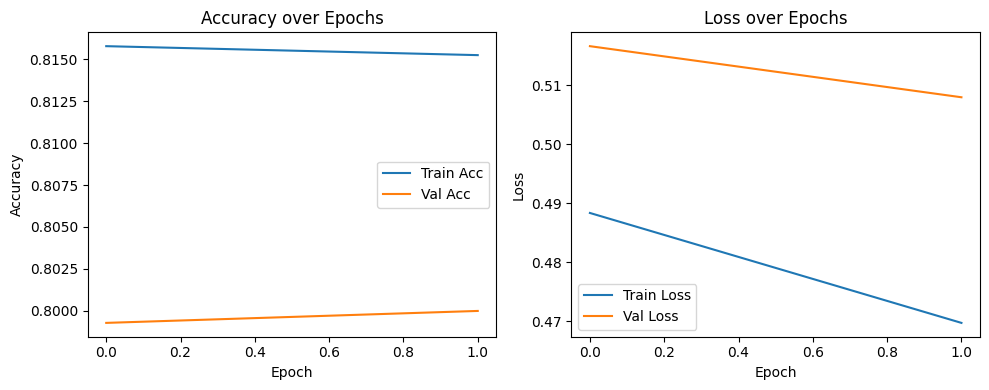

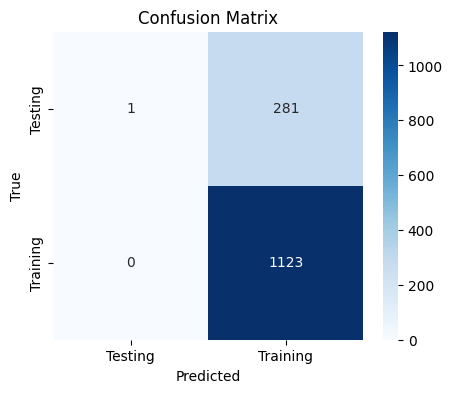

In [2]:
# Plotting Accuracy
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

# Plotting Loss
plt.subplot(1,2,2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.tight_layout()
plt.show()


import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

report = classification_report(all_labels, all_preds, target_names=class_names)
with open("classification_report.txt", "w") as f:
    f.write(report)


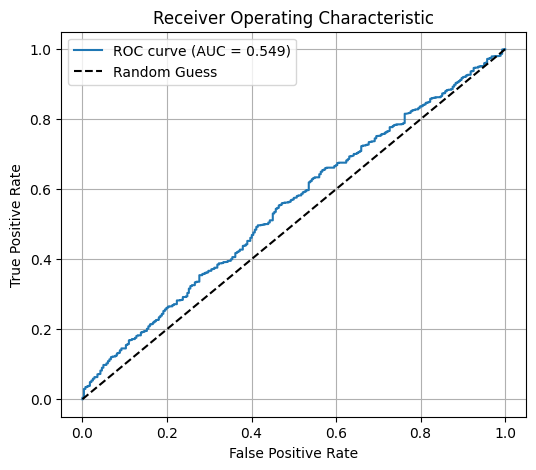

In [3]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend()
plt.grid(True)
plt.show()
